# Lab 3 — Stationarity, Autocovariance, and Autocorrelation

[Open this lab in Google Colab](https://colab.research.google.com/github/wanghemath/Book-MachineLearning2sda/blob/main/labs/chapter-03-stationarity-autocovariance-acf-lab.ipynb)

This lab is designed for **independent study**. It includes the background ideas before each programming task, then asks you to interpret what you see.

In Chapter 3, we move from simply plotting time series to asking a deeper question:

> When can the dependence pattern of a time series be summarized in a stable way?

The answer begins with **stationarity**. In this lab, you will simulate several processes and compare their sample autocorrelation functions.

## Learning goals

After completing this lab, you should be able to:

1. Explain the difference between strict stationarity and weak stationarity.
2. Compute the sample mean, variance, autocovariance, and autocorrelation.
3. Recognize white noise, random walks, MA(1), and AR(1) behavior from plots and ACF plots.
4. Explain why a random walk is not stationary even when its increments are stationary.
5. Use simulation to understand why sample ACF values vary from sample to sample.
6. Use AI tools responsibly to check reasoning, not to replace reasoning.

## Connection to the lecture notes

The lecture notes define a time series as a stochastic process indexed by time, then focus mostly on second-order quantities such as means and covariances. In this lab, we study those same objects computationally.


## 1. Mathematical background before programming

Let $\{X_t\}$ be a discrete-time stochastic process.

### 1.1 Mean function

The **mean function** is

$$
\mu_t = E[X_t].
$$

For a stationary process, the mean should not depend on $t$.

### 1.2 Autocovariance

The **autocovariance** between two time points $s$ and $t$ is

$$
\gamma_X(s,t) = \operatorname{Cov}(X_s,X_t)
= E[(X_s-\mu_s)(X_t-\mu_t)].
$$

For a weakly stationary process, this quantity depends only on the time lag $h=s-t$, not on the absolute time location.

### 1.3 Weak stationarity

A process is **weakly stationary** if:

1. $E[X_t]$ is constant in $t$.
2. $\operatorname{Cov}(X_{t+h},X_t)$ depends only on $h$.
3. $\operatorname{Var}(X_t)$ is finite.

In this course, when we say stationary without qualification, we usually mean weakly stationary.

### 1.4 Autocorrelation function

For a weakly stationary process, the autocovariance can be written as

$$
\gamma(h) = \operatorname{Cov}(X_{t+h},X_t).
$$

The **autocorrelation function**, or ACF, is

$$
\rho(h) = \frac{\gamma(h)}{\gamma(0)}.
$$

Because $\gamma(0)=\operatorname{Var}(X_t)$, the ACF measures dependence after standardizing by the variance.

### 1.5 Sample ACF

For observed data $x_0,x_1,\ldots,x_{n-1}$, define the sample mean

$$
\bar{x}=\frac{1}{n}\sum_{t=0}^{n-1}x_t.
$$

A common sample autocovariance estimate is

$$
\hat{\gamma}(h)=\frac{1}{n}\sum_{t=0}^{n-h-1}(x_{t+h}-\bar{x})(x_t-\bar{x}),
$$

and the sample ACF is

$$
\hat{\rho}(h)=\frac{\hat{\gamma}(h)}{\hat{\gamma}(0)}.
$$

The sample ACF is random because it is computed from one finite realization.


## 2. Setup

Run the following cell first. It imports the required libraries and defines helper functions.

This lab only uses standard scientific Python tools: `numpy`, `pandas`, and `matplotlib`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(7339)

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True


def sample_acf(x, max_lag=30):
    """Compute sample autocorrelation for lags 0, 1, ..., max_lag.

    This uses denominator n for all lags, matching a common time-series
    convention and making gamma_hat(0) the sample second central moment.
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    x_centered = x - x.mean()
    gamma0 = np.mean(x_centered * x_centered)
    acf_values = []
    for h in range(max_lag + 1):
        gamma_h = np.sum(x_centered[h:] * x_centered[: n - h]) / n
        acf_values.append(gamma_h / gamma0)
    return np.array(acf_values)


def plot_acf_manual(x, max_lag=30, title="Sample ACF"):
    """Make a simple ACF bar plot with approximate white-noise bands."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    acf_values = sample_acf(x, max_lag=max_lag)
    lags = np.arange(max_lag + 1)
    band = 1.96 / np.sqrt(n)

    plt.figure(figsize=(9, 4))
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1, label="approx. white-noise band")
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.vlines(lags, 0, acf_values, linewidth=2)
    plt.scatter(lags, acf_values, s=20)
    plt.xlabel("lag")
    plt.ylabel("sample ACF")
    plt.title(title)
    plt.ylim(-1.05, 1.05)
    plt.legend(loc="upper right")
    plt.show()

    return acf_values


def rolling_summary_plot(x, window=40, title="Time series with rolling mean and variance"):
    """Plot a series together with rolling mean and rolling variance."""
    x = pd.Series(np.asarray(x, dtype=float))
    rolling_mean = x.rolling(window).mean()
    rolling_var = x.rolling(window).var()

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    axes[0].plot(x.values, label="series")
    axes[0].plot(rolling_mean.values, label=f"rolling mean, window={window}")
    axes[0].set_title(title)
    axes[0].legend()

    axes[1].plot(rolling_var.values, label=f"rolling variance, window={window}")
    axes[1].set_xlabel("time")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def simulate_ar1(phi, n=300, burnin=200, sigma=1.0, seed=7339):
    """Simulate AR(1): X_t = phi X_{t-1} + W_t."""
    local_rng = np.random.default_rng(seed)
    total = n + burnin
    w = local_rng.normal(0, sigma, size=total)
    x = np.zeros(total)
    for t in range(1, total):
        x[t] = phi * x[t - 1] + w[t]
    return x[burnin:]


def simulate_ma1(theta, n=300, burnin=200, sigma=1.0, seed=7339):
    """Simulate MA(1): X_t = W_t + theta W_{t-1}."""
    local_rng = np.random.default_rng(seed)
    total = n + burnin
    w = local_rng.normal(0, sigma, size=total)
    x = np.zeros(total)
    for t in range(1, total):
        x[t] = w[t] + theta * w[t - 1]
    return x[burnin:]


def summarize_series(x, name="series"):
    x = np.asarray(x, dtype=float)
    return pd.Series({
        "name": name,
        "n": len(x),
        "mean": x.mean(),
        "variance": x.var(ddof=0),
        "minimum": x.min(),
        "maximum": x.max()
    })

print("Setup complete.")


Setup complete.


## 3. White noise

A **white noise** process has mean zero, constant variance, and no linear autocorrelation across time:

$$
E[X_t]=0, \qquad \operatorname{Var}(X_t)=\sigma^2, \qquad \operatorname{Cov}(X_s,X_t)=0 \text{ for } s\ne t.
$$

White noise can still have occasional large values. What makes it white noise is not that the plot looks flat, but that it has no systematic time dependence.

### Task

Simulate Gaussian white noise and inspect its plot and ACF.


In [2]:
n = 300
sigma = 1.0
white_noise = rng.normal(0, sigma, size=n)

summarize_series(white_noise, "Gaussian white noise")


,0
name,Gaussian white noise
n,300
mean,0.025136
variance,1.009296
minimum,-2.672223
maximum,3.175795


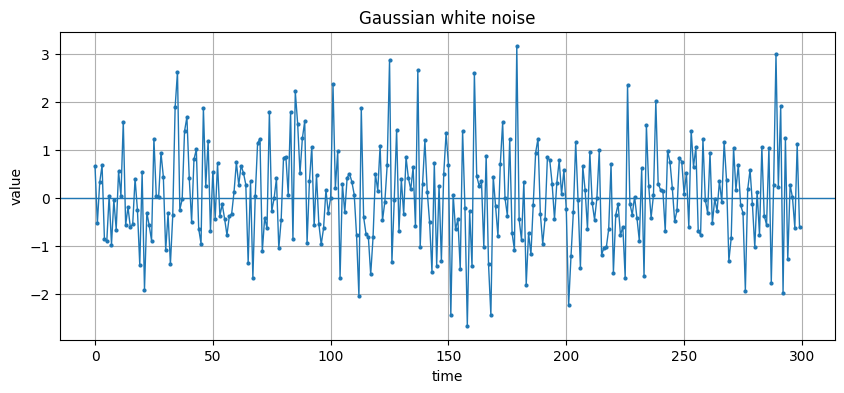

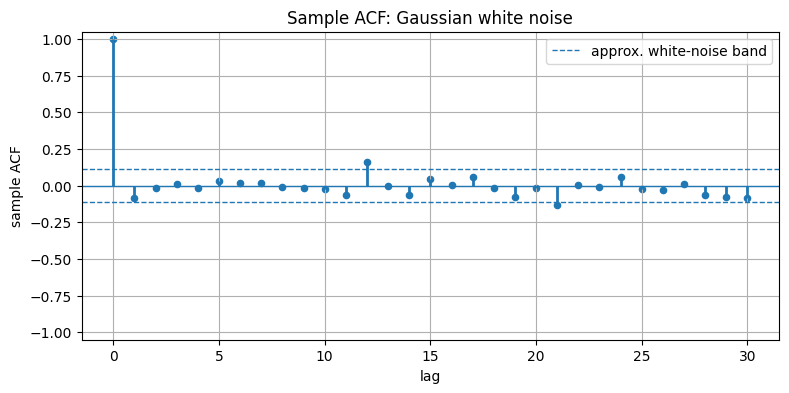

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(white_noise, marker="o", markersize=2, linewidth=1)
plt.axhline(0, linewidth=1)
plt.title("Gaussian white noise")
plt.xlabel("time")
plt.ylabel("value")
plt.show()

acf_wn = plot_acf_manual(white_noise, max_lag=30, title="Sample ACF: Gaussian white noise")


### Checkpoint 1

Answer these questions before moving on.

1. Is the sample mean exactly zero? Should it be exactly zero?
2. Are all sample autocorrelations exactly zero? Should they be exactly zero?
3. Why do we draw approximate bands $\pm 1.96/\sqrt{n}$ on the ACF plot?

**Interpretation:** For true white noise, most sample ACF values should be small, but some values may appear outside the bands by chance.


## 4. Binary i.i.d. process

The lecture notes also discuss a binary i.i.d. process:

$$
P(X_t=1)=p, \qquad P(X_t=-1)=1-p.
$$

When $p=1/2$, the process has mean zero. It is a simple example of a discrete-state time series.

Even though the values are only $-1$ and $1$, the sequence is still a time series because observations are indexed by time.


In [4]:
p = 0.5
binary_iid = rng.choice([-1, 1], size=n, p=[1-p, p])

summarize_series(binary_iid, "binary iid process")


,0
name,binary iid process
n,300
mean,-0.006667
variance,0.999956
minimum,-1.0
maximum,1.0


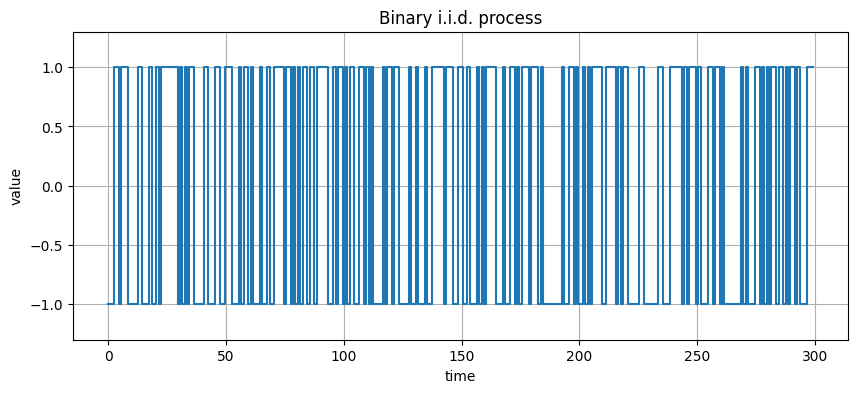

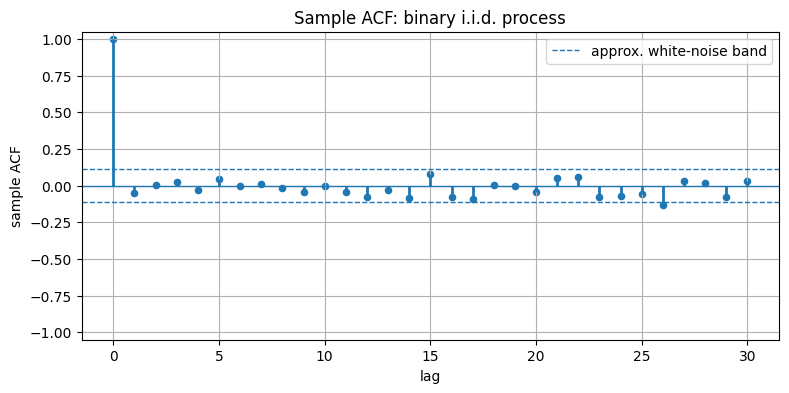

In [5]:
plt.figure(figsize=(10, 4))
plt.step(np.arange(n), binary_iid, where="mid")
plt.ylim(-1.3, 1.3)
plt.title("Binary i.i.d. process")
plt.xlabel("time")
plt.ylabel("value")
plt.show()

acf_binary = plot_acf_manual(binary_iid, max_lag=30, title="Sample ACF: binary i.i.d. process")


### Checkpoint 2

Compare Gaussian white noise and binary i.i.d. noise.

1. Do they have similar ACF behavior?
2. Do they have the same marginal distribution?
3. Why can two processes have very different distributions but similar autocorrelation structure?


## 5. Random walk: nonstationary level, stationary increments

A random walk is defined by

$$
S_t=S_{t-1}+W_t,
$$

or equivalently

$$
S_t=\sum_{i=1}^t W_i.
$$

If $W_t$ is white noise with variance $\sigma^2$, then

$$
E[S_t]=0, \qquad \operatorname{Var}(S_t)=t\sigma^2.
$$

The variance changes with time, so $S_t$ is not weakly stationary.

However, its first difference is

$$
\nabla S_t = S_t-S_{t-1}=W_t,
$$

which is stationary white noise.


In [6]:
random_walk_increments = rng.normal(0, 1, size=n)
random_walk = np.cumsum(random_walk_increments)

summaries = pd.concat([
    summarize_series(random_walk, "random walk"),
    summarize_series(random_walk_increments, "increments")
], axis=1).T
summaries


,name,n,mean,variance,minimum,maximum
0,random walk,300,16.683578,69.463853,1.359462,32.501289
1,increments,300,0.039405,0.994364,-3.524103,2.167048


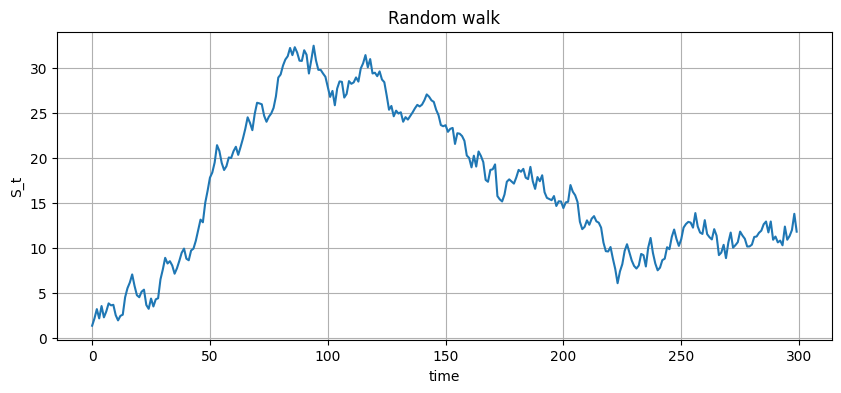

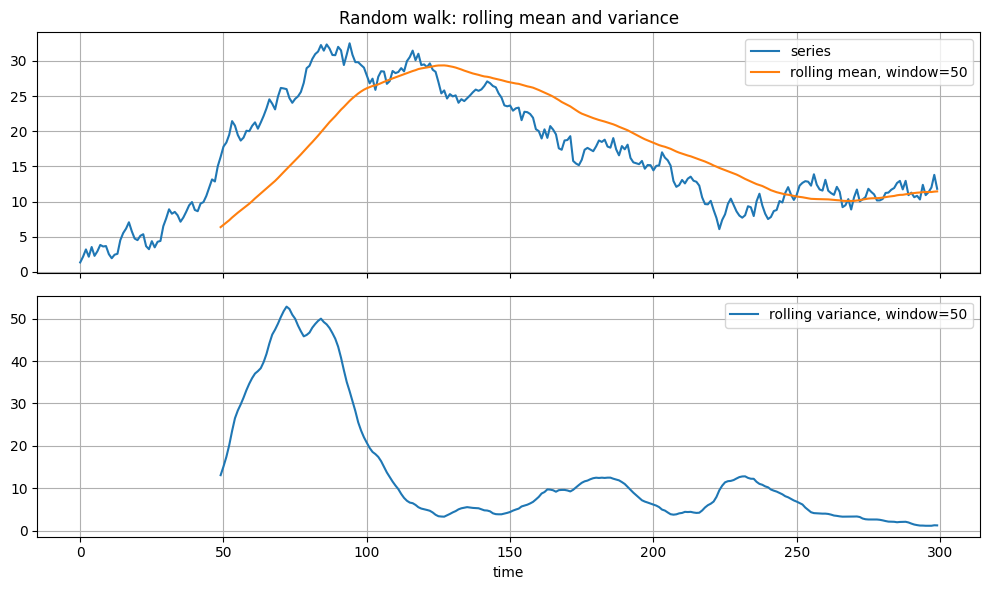

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(random_walk, linewidth=1.5)
plt.title("Random walk")
plt.xlabel("time")
plt.ylabel("S_t")
plt.show()

rolling_summary_plot(random_walk, window=50, title="Random walk: rolling mean and variance")


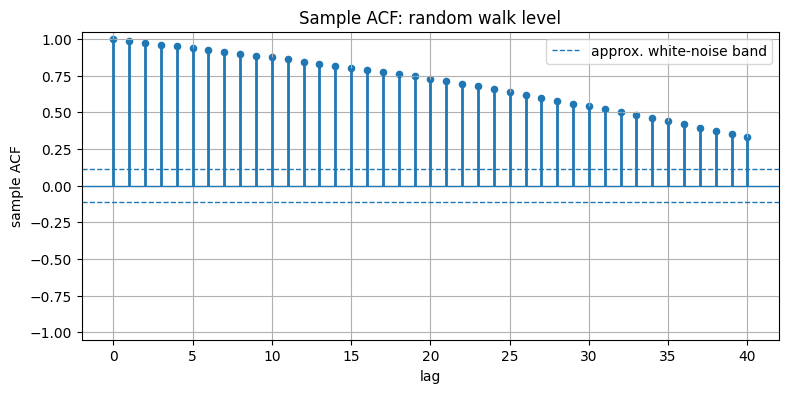

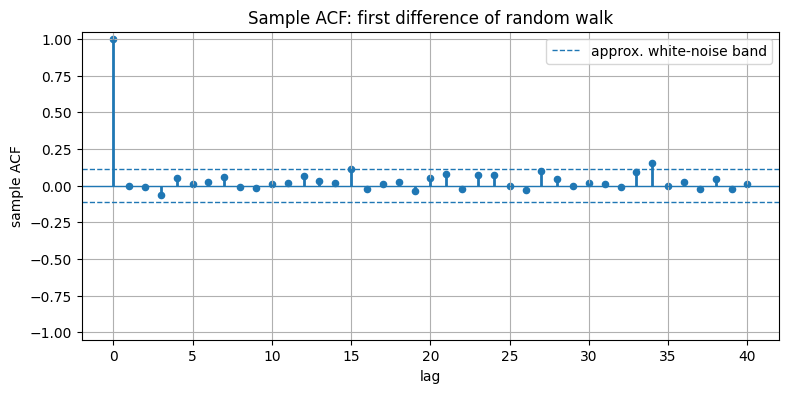

In [8]:
acf_rw = plot_acf_manual(random_walk, max_lag=40, title="Sample ACF: random walk level")
acf_diff_rw = plot_acf_manual(np.diff(random_walk), max_lag=40, title="Sample ACF: first difference of random walk")


### Checkpoint 3

1. Why does the random-walk ACF decay slowly?
2. Why is it misleading to treat the random-walk level as stationary?
3. Why does differencing help here?

**Important lesson:** A strong ACF can come from genuine stationary dependence, but it can also come from nonstationarity.


## 6. MA(1) process

A moving average process of order 1 is

$$
X_t=W_t+\theta W_{t-1},
$$

where $W_t$ is white noise.

For MA(1), the theoretical autocorrelation is

$$
\rho(1)=\frac{\theta}{1+\theta^2},
$$

and

$$
\rho(h)=0 \quad \text{for } |h|>1.
$$

This is why the ACF of an MA(1) process should **cut off** after lag 1, at least in theory. In a finite sample, the sample ACF will not be exactly zero after lag 1.


In [9]:
theta = 0.7
ma1 = simulate_ma1(theta=theta, n=n, seed=2026)

rho1_theory = theta / (1 + theta**2)
print(f"Theoretical MA(1) rho(1) = {rho1_theory:.3f}")

summarize_series(ma1, "MA(1)")


Theoretical MA(1) rho(1) = 0.470


,0
name,MA(1)
n,300
mean,0.002738
variance,1.763284
minimum,-3.359529
maximum,4.026545


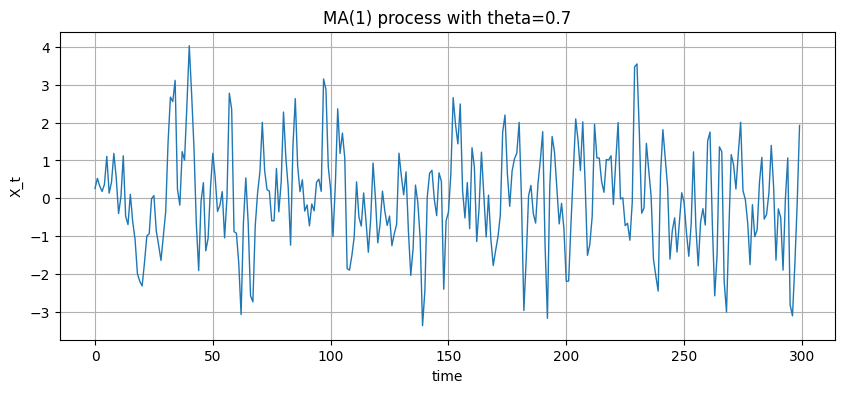

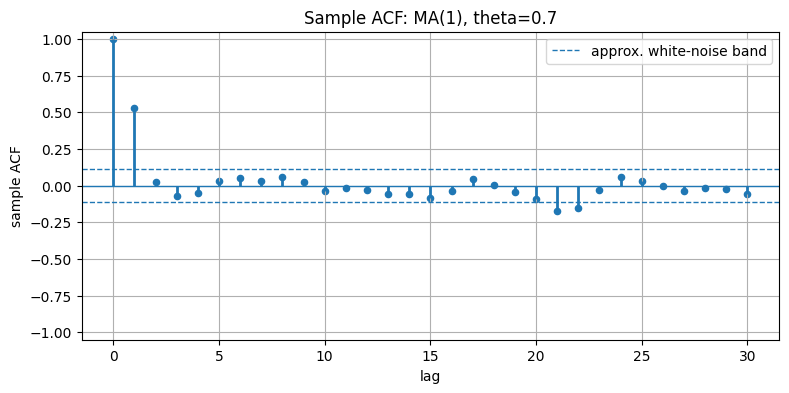

Sample rho_hat(1): 0.532


In [10]:
plt.figure(figsize=(10, 4))
plt.plot(ma1, linewidth=1)
plt.title(f"MA(1) process with theta={theta}")
plt.xlabel("time")
plt.ylabel("X_t")
plt.show()

acf_ma1 = plot_acf_manual(ma1, max_lag=30, title=f"Sample ACF: MA(1), theta={theta}")

print("Sample rho_hat(1):", round(acf_ma1[1], 3))


### Checkpoint 4

1. Compare the sample value $\hat{\rho}(1)$ with the theoretical value $\rho(1)$.
2. Are the lags after 1 exactly zero? Why not?
3. What ACF pattern would make you suspect an MA(1) model?


## 7. AR(1) process

An autoregressive process of order 1 is

$$
X_t=\phi X_{t-1}+W_t.
$$

When $|\phi|<1$, the AR(1) process has a stationary causal solution.

For stationary AR(1), the theoretical ACF is

$$
\rho(h)=\phi^{|h|}.
$$

So the ACF decays geometrically. Positive $\phi$ gives positive persistence. Negative $\phi$ gives alternating signs.


In [11]:
phi_pos = 0.75
phi_neg = -0.75
ar1_pos = simulate_ar1(phi=phi_pos, n=n, seed=2027)
ar1_neg = simulate_ar1(phi=phi_neg, n=n, seed=2028)

pd.concat([
    summarize_series(ar1_pos, "AR(1), phi=0.75"),
    summarize_series(ar1_neg, "AR(1), phi=-0.75")
], axis=1).T


,name,n,mean,variance,minimum,maximum
0,"AR(1), phi=0.75",300,0.158409,3.318215,-5.371929,4.007821
1,"AR(1), phi=-0.75",300,0.004778,1.988826,-4.462183,4.266771


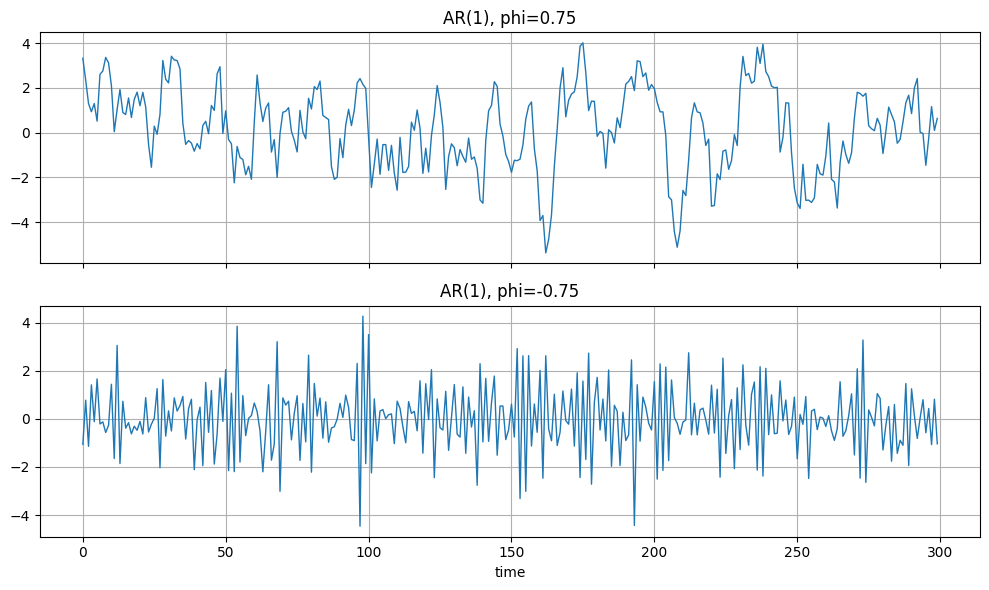

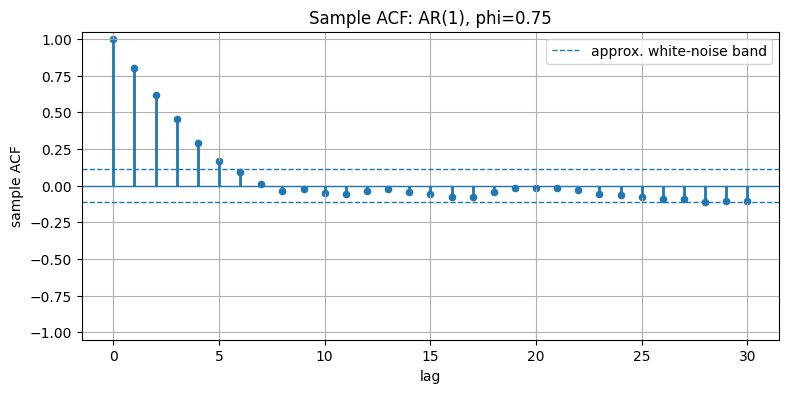

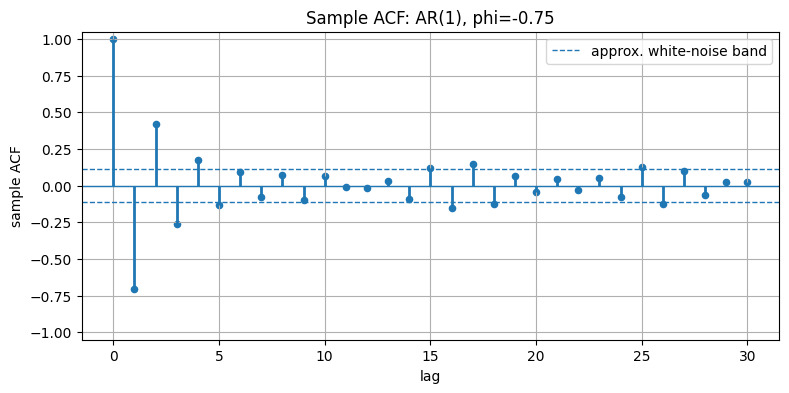

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(ar1_pos, linewidth=1)
axes[0].set_title("AR(1), phi=0.75")
axes[1].plot(ar1_neg, linewidth=1)
axes[1].set_title("AR(1), phi=-0.75")
axes[1].set_xlabel("time")
plt.tight_layout()
plt.show()

acf_ar1_pos = plot_acf_manual(ar1_pos, max_lag=30, title="Sample ACF: AR(1), phi=0.75")
acf_ar1_neg = plot_acf_manual(ar1_neg, max_lag=30, title="Sample ACF: AR(1), phi=-0.75")


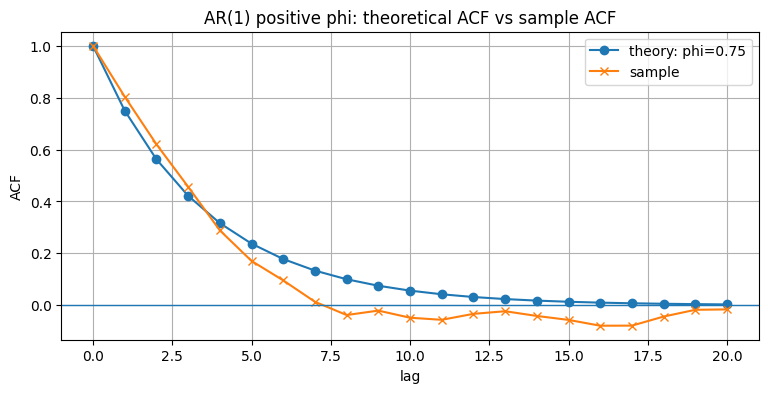

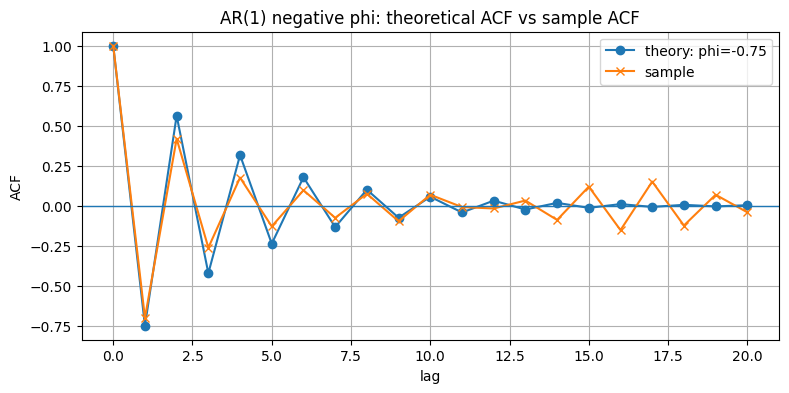

In [13]:
max_lag = 20
lags = np.arange(max_lag + 1)

plt.figure(figsize=(9, 4))
plt.plot(lags, phi_pos ** lags, marker="o", label="theory: phi=0.75")
plt.plot(lags, acf_ar1_pos[:max_lag + 1], marker="x", label="sample")
plt.axhline(0, linewidth=1)
plt.title("AR(1) positive phi: theoretical ACF vs sample ACF")
plt.xlabel("lag")
plt.ylabel("ACF")
plt.legend()
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(lags, phi_neg ** lags, marker="o", label="theory: phi=-0.75")
plt.plot(lags, acf_ar1_neg[:max_lag + 1], marker="x", label="sample")
plt.axhline(0, linewidth=1)
plt.title("AR(1) negative phi: theoretical ACF vs sample ACF")
plt.xlabel("lag")
plt.ylabel("ACF")
plt.legend()
plt.show()


### Checkpoint 5

1. For $\phi=0.75$, why does the ACF decay slowly but not cut off?
2. For $\phi=-0.75$, why does the ACF alternate signs?
3. How is the AR(1) ACF different from the MA(1) ACF?


## 8. Stationarity diagnostics using rolling summaries

Stationarity is a property of the data-generating process, not just one plot. Still, plots are useful diagnostics.

A stationary time series often has:

1. approximately stable mean,
2. approximately stable variance,
3. no deterministic trend,
4. no systematic change in dependence structure.

Let us compare four processes:

- white noise,
- stationary AR(1),
- random walk,
- trend plus noise.


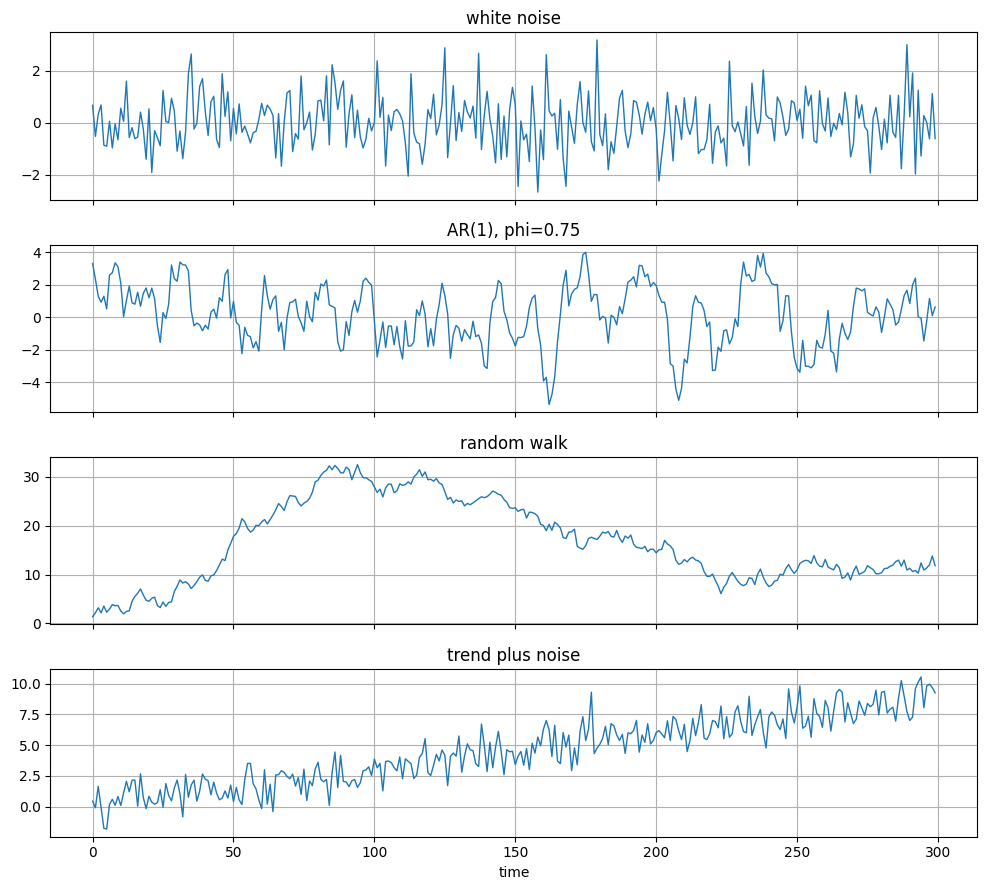

In [14]:
t = np.arange(n)
trend_plus_noise = 0.03 * t + rng.normal(0, 1, size=n)

processes = {
    "white noise": white_noise,
    "AR(1), phi=0.75": ar1_pos,
    "random walk": random_walk,
    "trend plus noise": trend_plus_noise,
}

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
for ax, (name, values) in zip(axes, processes.items()):
    ax.plot(values, linewidth=1)
    ax.set_title(name)
plt.xlabel("time")
plt.tight_layout()
plt.show()


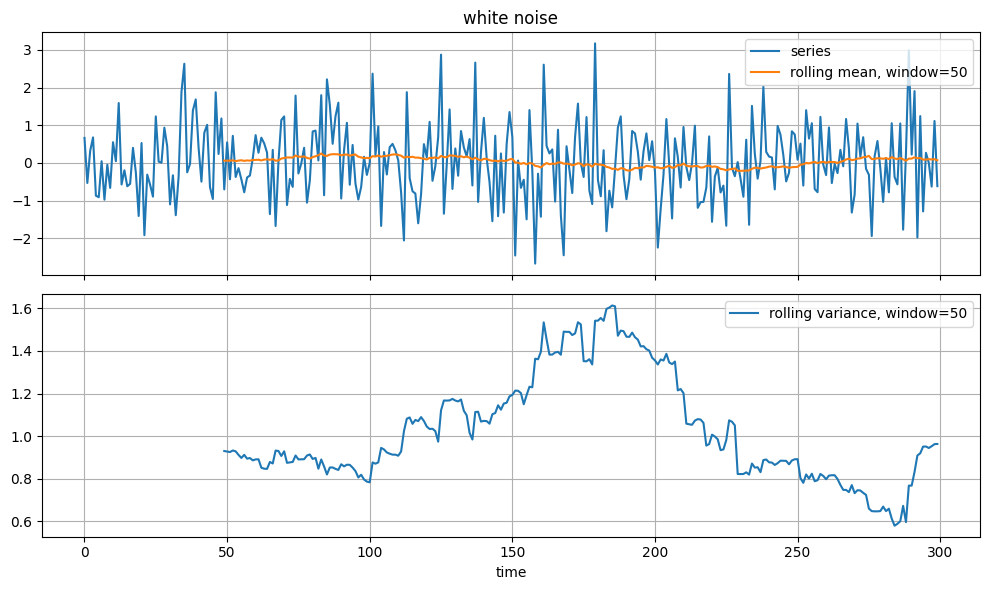

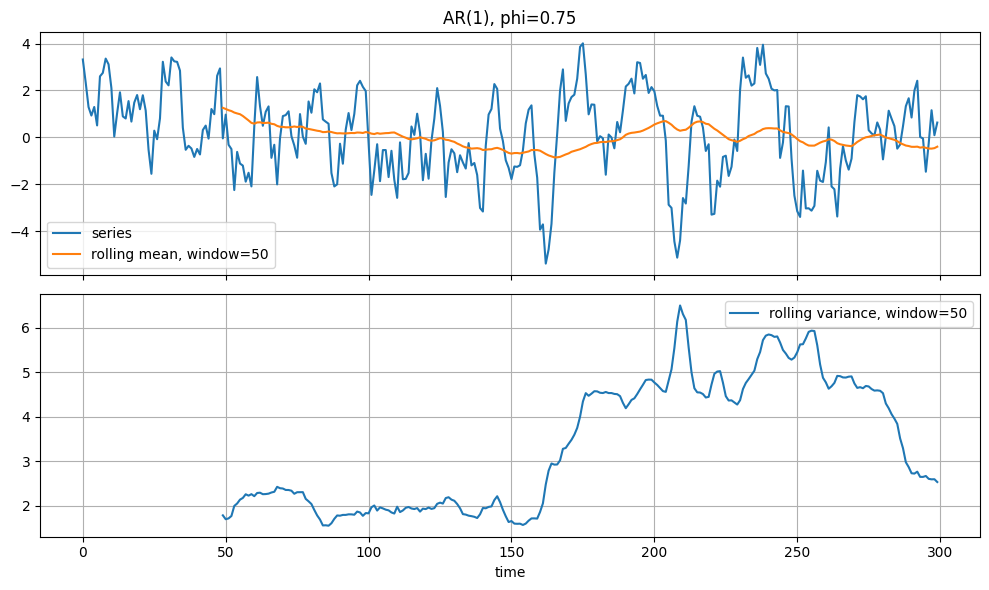

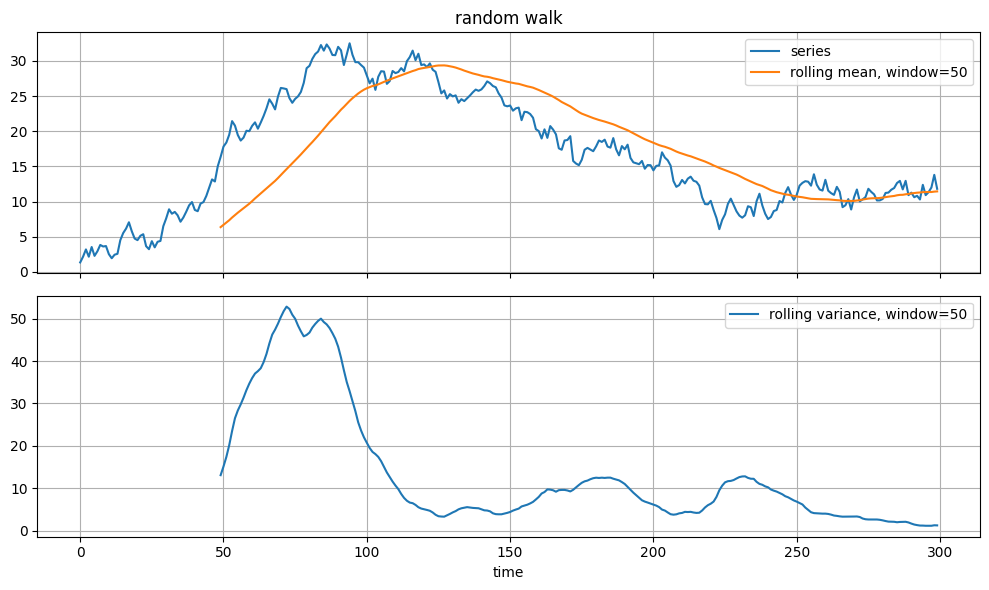

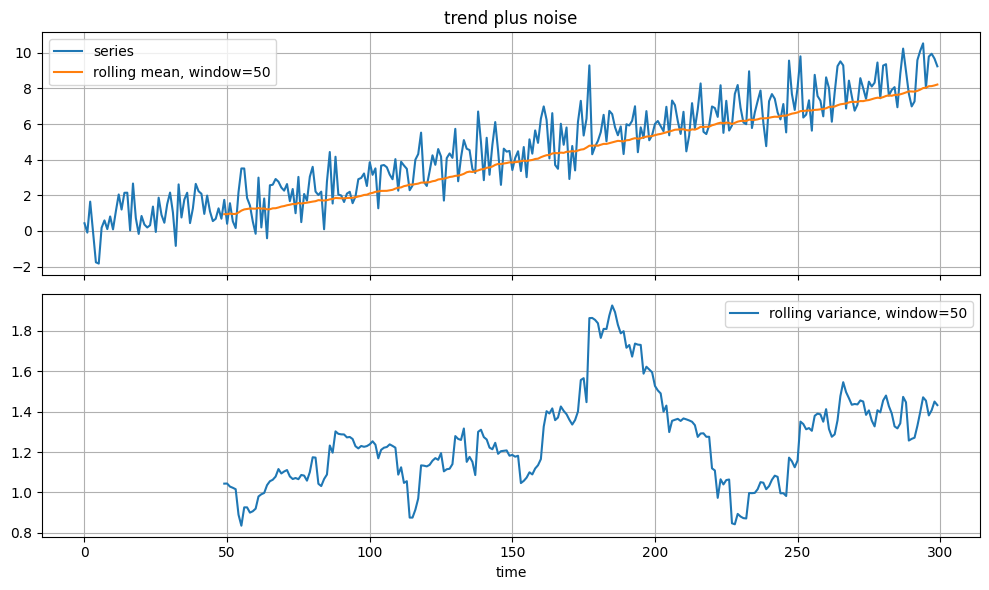

In [15]:
for name, values in processes.items():
    rolling_summary_plot(values, window=50, title=name)


### Checkpoint 6

For each of the four processes, write whether it appears stationary or nonstationary.

Be careful:

- A stationary process can have temporary upward and downward movements.
- A nonstationary process can sometimes look stable over a short time window.
- A plot alone is not proof, but it guides model choice.


## 9. Model identification from ACF patterns

A very useful first diagnostic is to compare ACF patterns.

Common patterns:

| Process | Typical ACF pattern |
|---|---|
| White noise | near zero after lag 0 |
| MA(1) | nonzero at lag 1, near zero after lag 1 |
| AR(1), positive $\phi$ | positive geometric decay |
| AR(1), negative $\phi$ | alternating geometric decay |
| Random walk | very slow decay, often near 1 for many lags |

Let us plot the ACFs together.


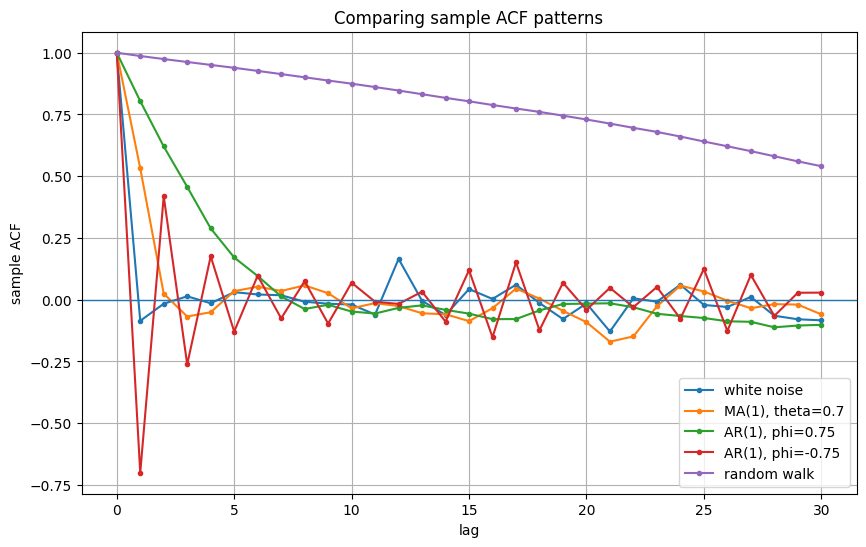

In [16]:
comparison = {
    "white noise": white_noise,
    "MA(1), theta=0.7": ma1,
    "AR(1), phi=0.75": ar1_pos,
    "AR(1), phi=-0.75": ar1_neg,
    "random walk": random_walk,
}

max_lag = 30
lags = np.arange(max_lag + 1)

plt.figure(figsize=(10, 6))
for name, values in comparison.items():
    plt.plot(lags, sample_acf(values, max_lag=max_lag), marker="o", markersize=3, label=name)
plt.axhline(0, linewidth=1)
plt.title("Comparing sample ACF patterns")
plt.xlabel("lag")
plt.ylabel("sample ACF")
plt.legend()
plt.show()


### Checkpoint 7

Use the combined ACF plot to answer:

1. Which process has the clearest cut-off behavior?
2. Which process has the clearest geometric decay?
3. Which process should not be treated as stationary?
4. Which process would be hardest to identify from a short sample?


## 10. Simulation study: sample ACF variability

The sample ACF is random. Even for true white noise, some sample autocorrelations can appear large.

For a rough white-noise diagnostic, we often use the band

$$
\pm \frac{1.96}{\sqrt{n}}.
$$

But with many lags, it is not surprising that one or two values may fall outside this band.

Let us simulate many white-noise series and count how often at least one lag from 1 to 30 exceeds the band.


In [17]:
num_simulations = 500
max_lag = 30
n_sim = 300
band = 1.96 / np.sqrt(n_sim)

outside_counts = []
max_abs_acfs = []

for _ in range(num_simulations):
    x = rng.normal(0, 1, size=n_sim)
    acf_vals = sample_acf(x, max_lag=max_lag)[1:]  # exclude lag 0
    outside_counts.append(np.sum(np.abs(acf_vals) > band))
    max_abs_acfs.append(np.max(np.abs(acf_vals)))

outside_counts = np.array(outside_counts)
max_abs_acfs = np.array(max_abs_acfs)

print("Band:", round(band, 3))
print("Average number of lags outside band:", round(outside_counts.mean(), 3))
print("Proportion with at least one lag outside band:", round(np.mean(outside_counts >= 1), 3))


Band: 0.113
Average number of lags outside band: 1.316
Proportion with at least one lag outside band: 0.712


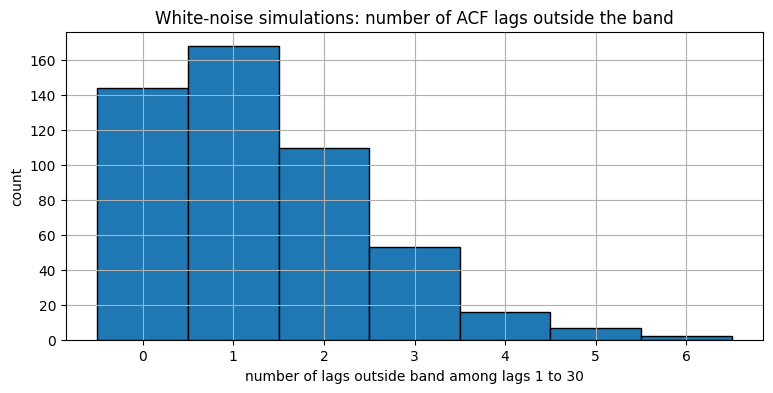

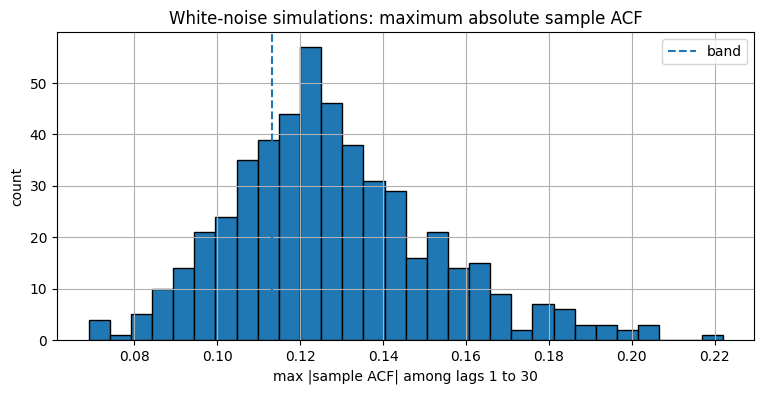

In [18]:
plt.figure(figsize=(9, 4))
plt.hist(outside_counts, bins=np.arange(outside_counts.max() + 2) - 0.5, edgecolor="black")
plt.title("White-noise simulations: number of ACF lags outside the band")
plt.xlabel("number of lags outside band among lags 1 to 30")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(9, 4))
plt.hist(max_abs_acfs, bins=30, edgecolor="black")
plt.axvline(band, linestyle="--", label="band")
plt.title("White-noise simulations: maximum absolute sample ACF")
plt.xlabel("max |sample ACF| among lags 1 to 30")
plt.ylabel("count")
plt.legend()
plt.show()


### Checkpoint 8

1. Does a single ACF spike outside the band prove that the process is not white noise?
2. Why should we look at the overall ACF pattern rather than one isolated lag?
3. How does sample size affect the width of the band?


## 11. Mini-project: identify an unknown process

The following cell creates four unlabeled series. Your job is to inspect their time plots and ACF plots, then guess which is which.

Possible models:

- white noise,
- MA(1),
- AR(1),
- random walk.

Do not look at the answer key until after you write your guesses.


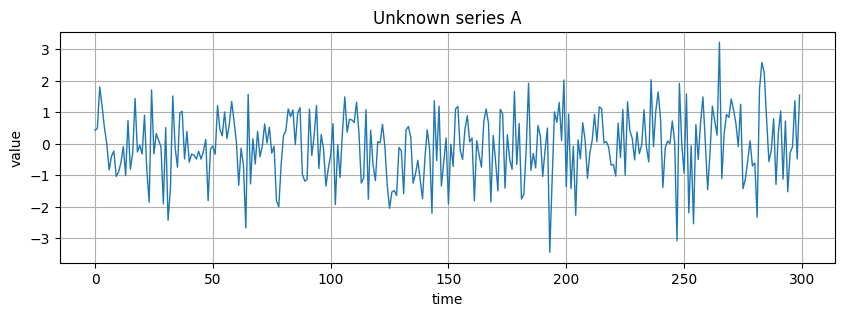

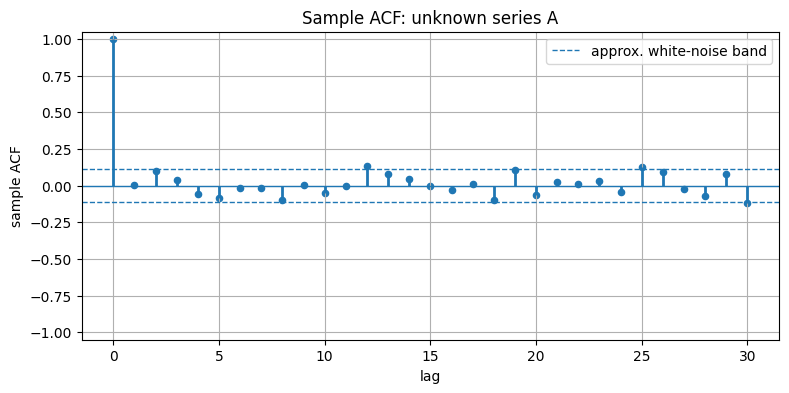

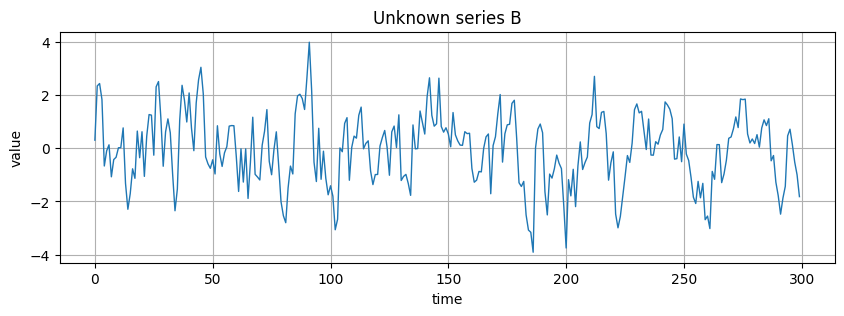

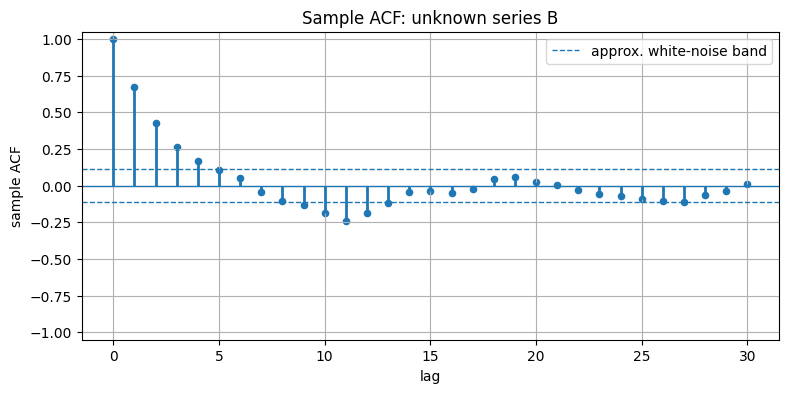

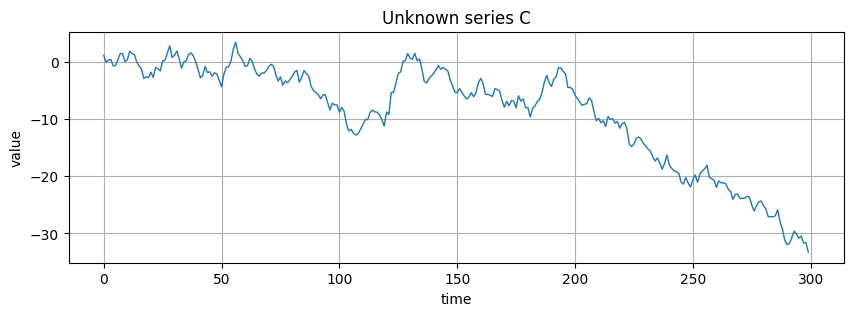

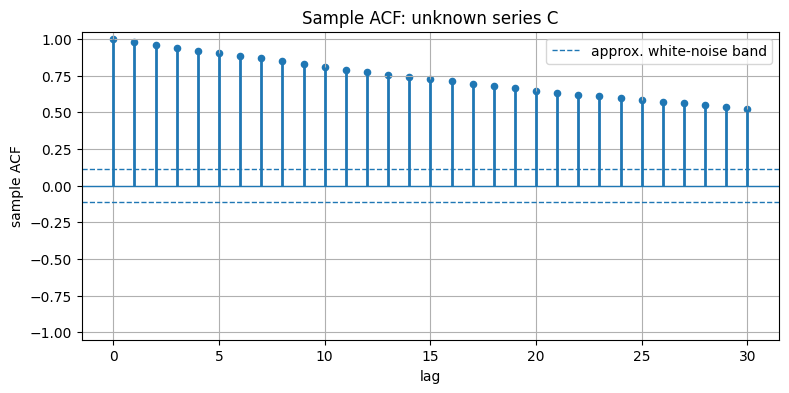

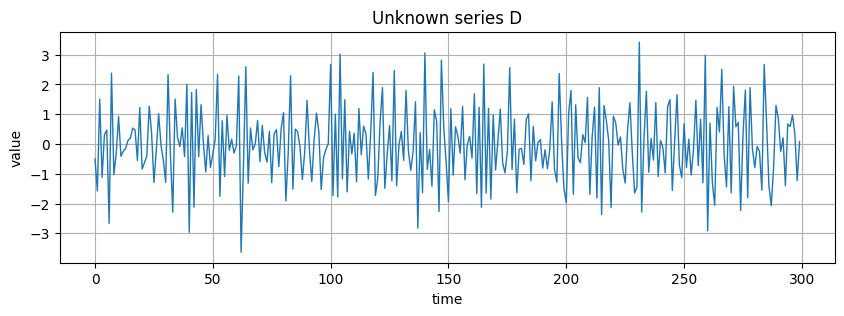

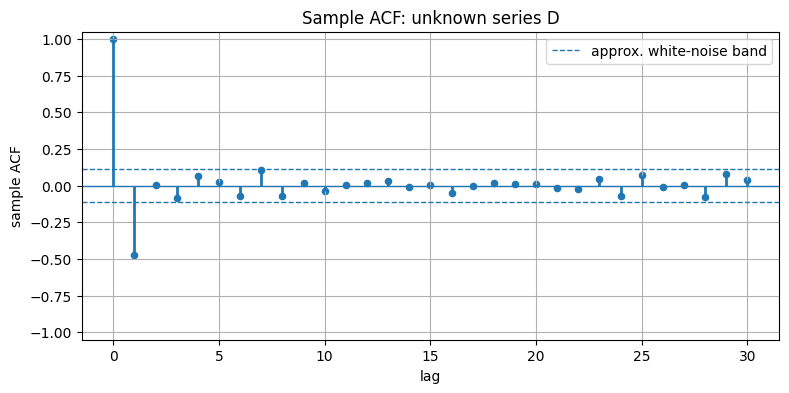

In [19]:
unknown_series = {
    "A": rng.normal(0, 1, size=n),
    "B": simulate_ar1(phi=0.65, n=n, seed=9001),
    "C": np.cumsum(rng.normal(0, 1, size=n)),
    "D": simulate_ma1(theta=-0.8, n=n, seed=9002),
}

for label, values in unknown_series.items():
    plt.figure(figsize=(10, 3))
    plt.plot(values, linewidth=1)
    plt.title(f"Unknown series {label}")
    plt.xlabel("time")
    plt.ylabel("value")
    plt.show()

    plot_acf_manual(values, max_lag=30, title=f"Sample ACF: unknown series {label}")


### Your guesses

Write your guesses here before revealing the answer.

- Unknown A:
- Unknown B:
- Unknown C:
- Unknown D:

Explain each guess using both the time plot and the ACF plot.


In [20]:
answer_key = {
    "A": "white noise",
    "B": "AR(1), positive phi",
    "C": "random walk",
    "D": "MA(1), negative theta",
}

answer_key


{'A': 'white noise',
 'B': 'AR(1), positive phi',
 'C': 'random walk',
 'D': 'MA(1), negative theta'}

## 12. AI-assisted study prompts

Use an AI assistant only after you have completed your own interpretation. Good prompts ask for explanation and verification, not just answers.

### Prompt 1: Concept check

> I simulated white noise, an MA(1), an AR(1), and a random walk. Explain how their ACF plots should differ. Focus on stationarity and dependence, not just visual appearance.

### Prompt 2: Debugging code

> Here is my function for computing the sample ACF. Please check whether it correctly centers the data and handles lag 0. Explain any bug you find.

### Prompt 3: Interpretation check

> I see one ACF spike outside the approximate white-noise band. Does that prove my process is not white noise? Explain using finite-sample variability.

### Prompt 4: Mathematical explanation

> Explain why the random walk $S_t=\sum_{i=1}^t W_i$ is not weakly stationary but its first difference is stationary.

### Responsible AI rule

Always ask the AI assistant to explain the reasoning. Then compare the answer with your plots, formulas, and simulation results.


## 13. Exercises

### Exercise 1

Simulate an AR(1) process for $\phi=0.2$, $0.6$, and $0.95$. Compare their ACF plots. What happens as $\phi$ approaches 1?

### Exercise 2

Simulate an MA(1) process for $\theta=-0.8$, $0$, and $0.8$. Compare their ACF plots. What changes at lag 1?

### Exercise 3

For an MA(1) process, verify numerically that

$$
\rho(1)=\frac{\theta}{1+\theta^2}.
$$

Try several values of $\theta$ and compare sample ACF values with the theoretical value.

### Exercise 4

Create a trend-plus-noise series

$$
X_t=0.05t+W_t.
$$

Plot the series and its ACF. Then detrend it by fitting a line and computing residuals. Compare the ACF before and after detrending.

### Exercise 5

Repeat the white-noise simulation study with $n=100$, $n=500$, and $n=2000$. How does the white-noise band change?


## 14. Lab checklist

Before you finish, make sure you can do the following without looking at the solutions:

- [ ] Define weak stationarity in words.
- [ ] Explain the difference between autocovariance and autocorrelation.
- [ ] Compute a sample ACF from scratch.
- [ ] Explain why white noise has nearly zero sample ACF values after lag 0.
- [ ] Explain why random walks are nonstationary.
- [ ] Identify the ACF cut-off pattern of MA(1).
- [ ] Identify the geometric decay pattern of AR(1).
- [ ] Explain why finite-sample ACF plots are noisy.

You are now ready for Chapter 4, where AR, MA, and ARMA models are studied more systematically using backshift operators, causality, invertibility, and linear-process representations.
